In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, r2_score

class ForestRegressions2:
    def __init__(self, df_train:pd.DataFrame, df_test:pd.DataFrame):
        self.df_train = df_train
        self.df_test = df_test
        self.features = df_train.columns
        self.models = {}

    def fit(self,feature_list:list, param_list=None):

        tscv = TimeSeriesSplit(n_splits=5)

        X_train = self.df_train[feature_list]
        y_train = self.df_train['solar']
        
        if param_list is None:
            param_list = {
            'n_estimators': [50, 100, 200],
            'max_depth': [2, 5, 10],
            'min_samples_split': [3, 4, 10],
            'min_samples_leaf': [3, 4, 10]}

        search = GridSearchCV(RandomForestRegressor(),param_grid=param_list,cv=tscv,scoring='neg_root_mean_squared_error',n_jobs=-1)
        search.fit(X_train,y_train)
        
        self.models[tuple(feature_list)] = search.best_estimator_

    def get_model(self, feature_list:list):
        return self.models.get(tuple(feature_list))
    
    def predictions(self, feature_list:list):
        model = self.get_model(tuple(feature_list))
        df = self.df_test[["solar"]].copy()
        df['Prediction'] = model.predict(self.df_test[feature_list])
        return df

class ExtraTreesRegressions2:
    def __init__(self, df_train:pd.DataFrame, df_test:pd.DataFrame):
        self.df_train = df_train
        self.df_test = df_test
        self.features = df_train.columns
        self.models = {}

    def fit(self,feature_list:list, param_list=None):

        tscv = TimeSeriesSplit(n_splits=5)

        X_train = self.df_train[feature_list]
        y_train = self.df_train['solar']
        
        if param_list is None:
            param_list = {
            'n_estimators': [50, 100, 200, 500],
            'max_depth': [None, 2, 5],
            'min_samples_split': [3, 4, 10],
            'min_samples_leaf': [3, 4, 10]}

        search = GridSearchCV(ExtraTreesRegressor(),param_grid=param_list,cv=tscv,scoring='neg_root_mean_squared_error',n_jobs=-1)
        search.fit(X_train,y_train)
        
        self.models[tuple(feature_list)] = search.best_estimator_

    def get_model(self, feature_list:list):
        return self.models.get(tuple(feature_list))
    
    def predictions(self, feature_list:list):
        model = self.get_model(tuple(feature_list))
        df = self.df_test[["solar"]].copy()
        df['Prediction'] = model.predict(self.df_test[feature_list])
        return df

class XGBoostRegressions2:
    def __init__(self, df_train:pd.DataFrame, df_test:pd.DataFrame):
        self.df_train = df_train
        self.df_test = df_test
        self.features = df_train.columns
        self.models = {}

    def fit(self,feature_list:list, param_list=None):

        tscv = TimeSeriesSplit(n_splits=5)

        X_train = self.df_train[feature_list]
        y_train = self.df_train['solar']
        
        if param_list is None:
            param_list = {
                'n_estimators': [100, 200, 300, 400, 500],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5, 7],
                'subsample': [0.8, 1.0]}

        search = GridSearchCV(XGBRegressor(),param_grid=param_list,cv=tscv,scoring='neg_root_mean_squared_error',n_jobs=-1)
        search.fit(X_train,y_train)
        
        self.models[tuple(feature_list)] = search.best_estimator_


    def get_model(self, feature_list:list):
        return self.models.get(tuple(feature_list))
    
    def predictions(self, feature_list:list):
        model = self.get_model(tuple(feature_list))
        df = self.df_test[["solar"]].copy()
        df['Prediction'] = model.predict(self.df_test[feature_list])
        return df
    
def plot_data2(title:str,df:pd.DataFrame,day=None):
    if day is not None:#Optional day argument starts are chosen day
        start = pd.Timestamp(year=df.index.year[1],month=1,day=1).tz_localize('UTC')+pd.Timedelta(days=day-1)
        end = start+pd.Timedelta(days=14)
    else:#Otherwise randomly choose a day to begin plot
        days = [day for day in df.index.unique() if day.day_of_year < 350]
        start = np.random.choice(days)
        end = start+pd.Timedelta(days=14)

    plot_df = df.asfreq('h')#Add NaN rows so pyplot skips interpolation across jumps
    plot_df = plot_df.loc[start:end]

    #Metrics added to plot labeling
    rmse = root_mean_squared_error(df['solar'],df['Prediction'])
    r2 = r2_score(df['solar'],df['Prediction'])

    plt.figure(figsize=(20, 5))
    plt.plot(plot_df.index, plot_df['solar'], label='Actual solar', alpha=0.5)
    plt.plot(plot_df.index, plot_df['Prediction'], label='Predicted Energy', linestyle='--', alpha=0.9)
    plt.title(f"Actual vs Predicted Solar Energy in CO over Time ({title})")
    plt.xlabel("Time")
    plt.ylabel("Solar Energy CO")
    plt.text(0.94,1.05,f'RMSE: {rmse:.2f}\n r2: {r2:.4f}',transform=plt.gca().transAxes,bbox=dict(boxstyle="square", facecolor="white"))
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_daily_data2(title:str,df:pd.DataFrame):
    #Convert dataframe of hourly data to daily data of total energy
    df_daily = df.resample('d').agg('sum')

    #Metrics added to plot labeling
    rmse = root_mean_squared_error(df_daily['solar'],df_daily['Prediction'])
    r2 = r2_score(df_daily['solar'],df_daily['Prediction'])

    plt.figure(figsize=(20, 5))
    sns.scatterplot(df_daily, x=df_daily.index,y='solar',label='Actual Energy')
    sns.scatterplot(df_daily, x=df_daily.index,y='Prediction',label='Predicted Energy')
    plt.title(f"Actual vs Predicted Energy Over Time Daily Total ({title})")
    plt.xlabel("Time")
    plt.ylabel("Solar Energy CO per day")
    plt.text(0.94,1.05,f'RMSE: {rmse:.2f}\n r2: {r2:.4f}',transform=plt.gca().transAxes,bbox=dict(boxstyle="square", facecolor="white"))
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()  




In [3]:
SolarData22 = pd.read_csv('../data/Processed/Solar2022.csv',index_col=0,parse_dates=[0])
SolarData23 = pd.read_csv('../data/Processed/Solar2023.csv',index_col=0,parse_dates=[0])
SolarData24 = pd.read_csv('../data/Processed/Solar2024.csv',index_col=0,parse_dates=[0])

co22 = pd.read_csv('../data/Processed/co22.csv',index_col=0,parse_dates=[0])
co23 = pd.read_csv('../data/Processed/co23.csv',index_col=0,parse_dates=[0])
co24 = pd.read_csv('../data/Processed/co24.csv',index_col=0,parse_dates=[0])

com_2022 = SolarData22.join(co22, how='inner')
com_2023 = SolarData23.join(co23, how='inner')
com_2024 = SolarData24.join(co24, how='inner')

#Add energy lag columns so forests can partially involve time
com22Lags = com_2022.copy()
com23Lags = com_2023.copy()
com24Lags = com_2024.copy()

for lag in [6,24,48,72,168, 336]:
    com22Lags[f'Energy Lag {lag}'] = com_2022['solar'].shift(lag)
    com23Lags[f'Energy Lag {lag}'] = com_2023['solar'].shift(lag)
    com24Lags[f'Energy Lag {lag}'] = com_2024['solar'].shift(lag)
com22Lags.dropna(inplace=True)
com23Lags.dropna(inplace=True)
com24Lags.dropna(inplace=True)

c22 = com22Lags[com22Lags['Solar Zenith Angle']<np.pi/2]
c23 = com23Lags[com23Lags['Solar Zenith Angle']<np.pi/2]
c24 = com24Lags[com24Lags['Solar Zenith Angle']<np.pi/2]





c22.loc[:, 'capacity'] = 1871.5
c23.loc[:,'capacity']= 2167.5
c24.loc[:, 'capacity']= 2170.9

C:\Users\jumo2729\AppData\Local\Temp\ipykernel_1268\1383705383.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c22.loc[:, 'capacity'] = 1871.5
C:\Users\jumo2729\AppData\Local\Temp\ipykernel_1268\1383705383.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c23.loc[:,'capacity']= 2167.5
C:\Users\jumo2729\AppData\Local\Temp\ipykernel_1268\1383705383.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead


In [4]:
SolarTrainA = pd.concat([c22, c23])
SolarTestA = c24.copy()

RandomForestModels2 = ForestRegressions2(SolarTrainA,SolarTestA)
ExtraTreeModels2 = ExtraTreesRegressions2(SolarTrainA,SolarTestA)
XGBoostModels2 = XGBoostRegressions2(SolarTrainA,SolarTestA)

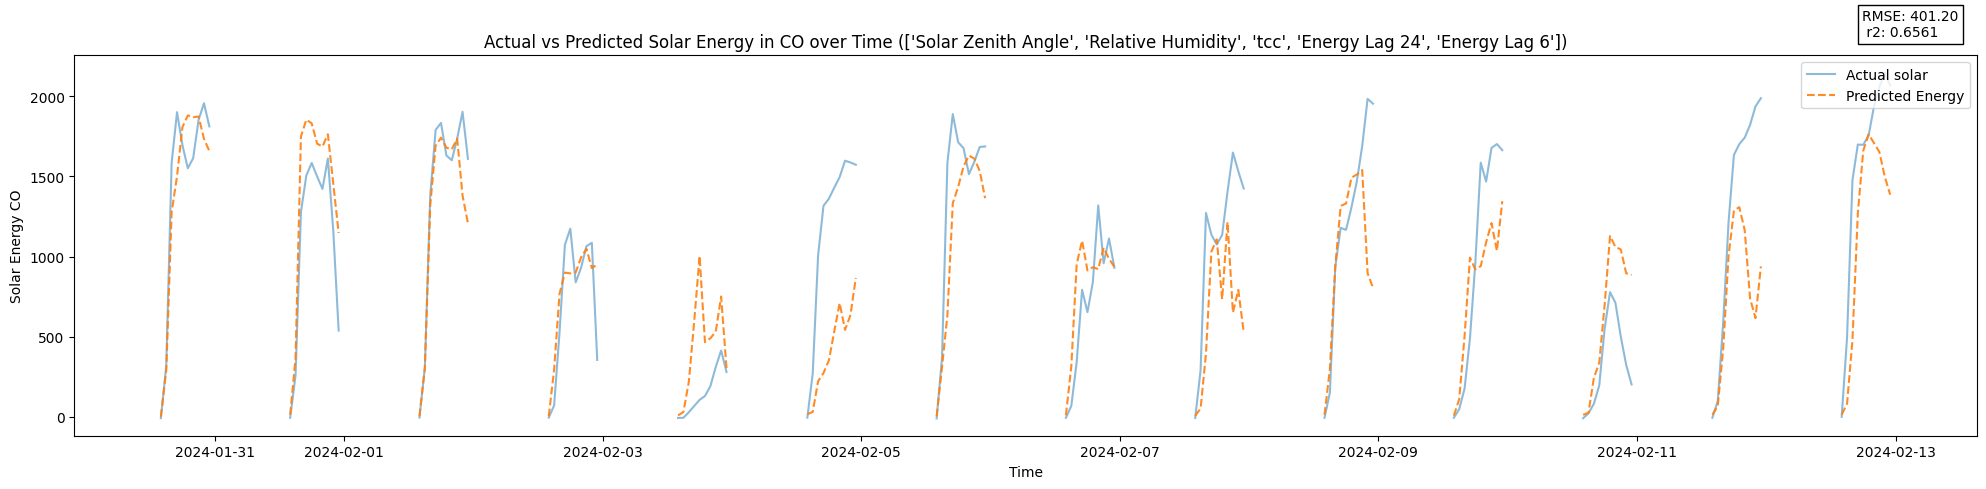

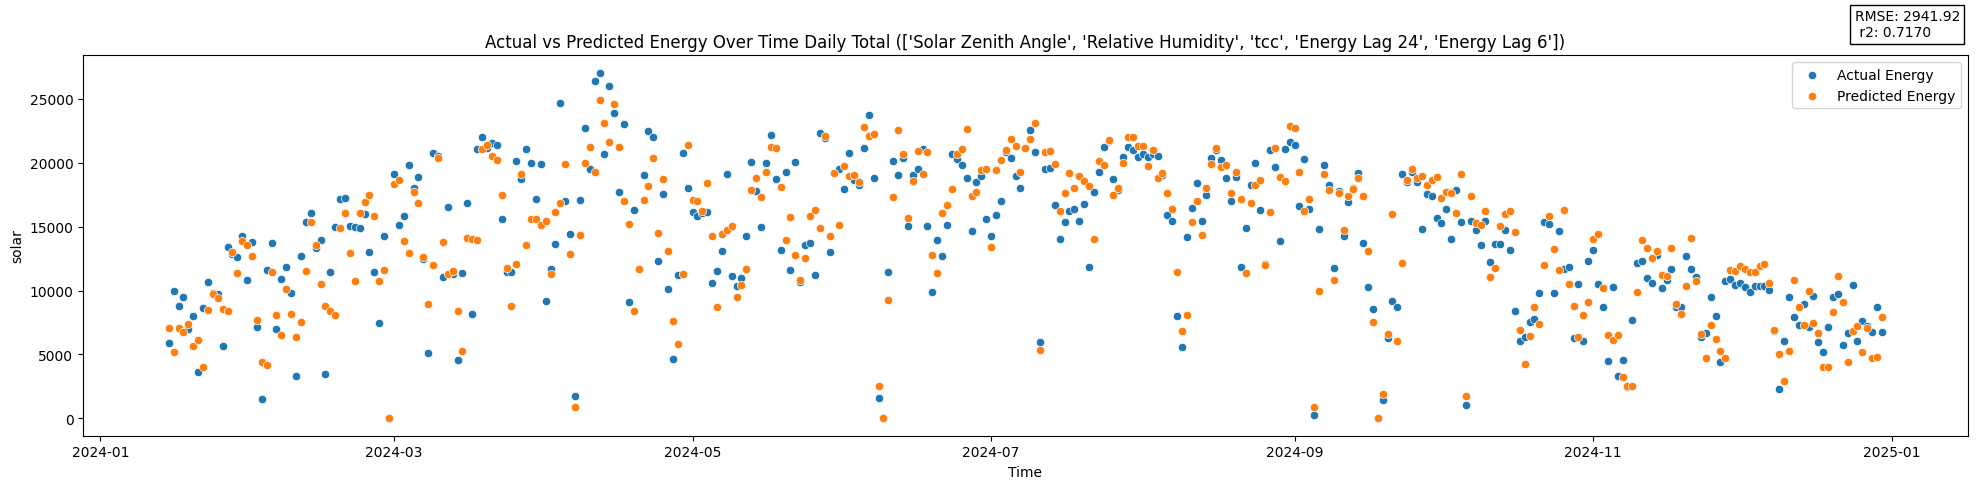

In [28]:
features = ['Solar Zenith Angle', 'Relative Humidity', 'tcc','Energy Lag 24', 'Energy Lag 6']
RandomForestModels2.fit(features)

plot_data2(features,RandomForestModels2.predictions(features),30)
plot_daily_data2(features,RandomForestModels2.predictions(features))

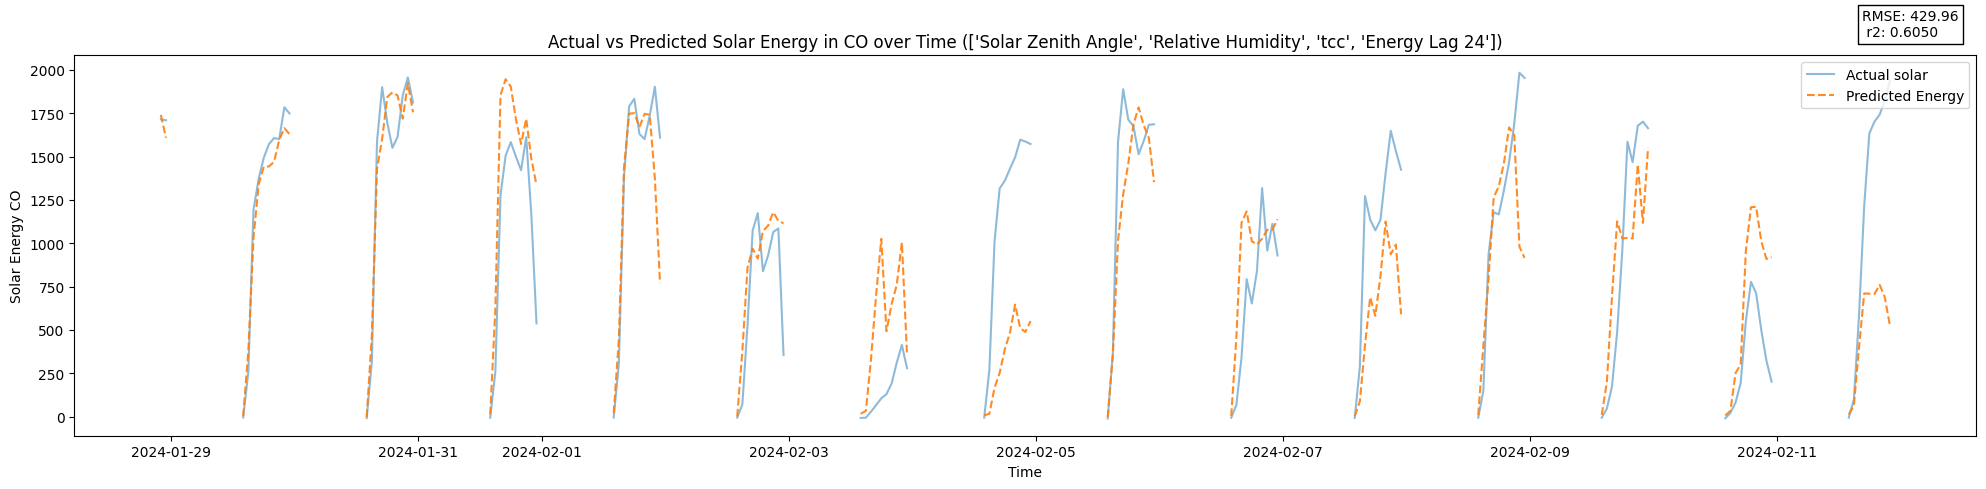

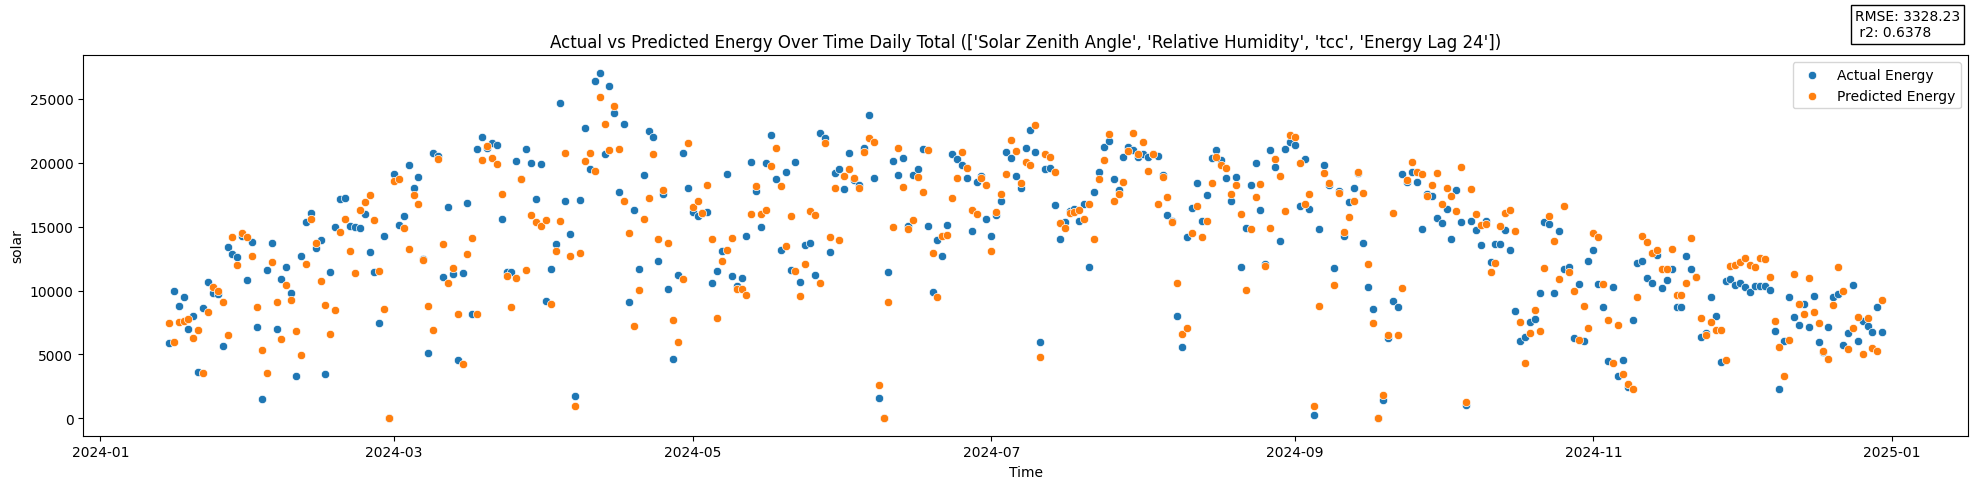

In [30]:
features = ['Solar Zenith Angle','Relative Humidity','tcc','Energy Lag 24']
ExtraTreeModels2.fit(features)
plot_data2(features,ExtraTreeModels2.predictions(features))
plot_daily_data2(features,ExtraTreeModels2.predictions(features))

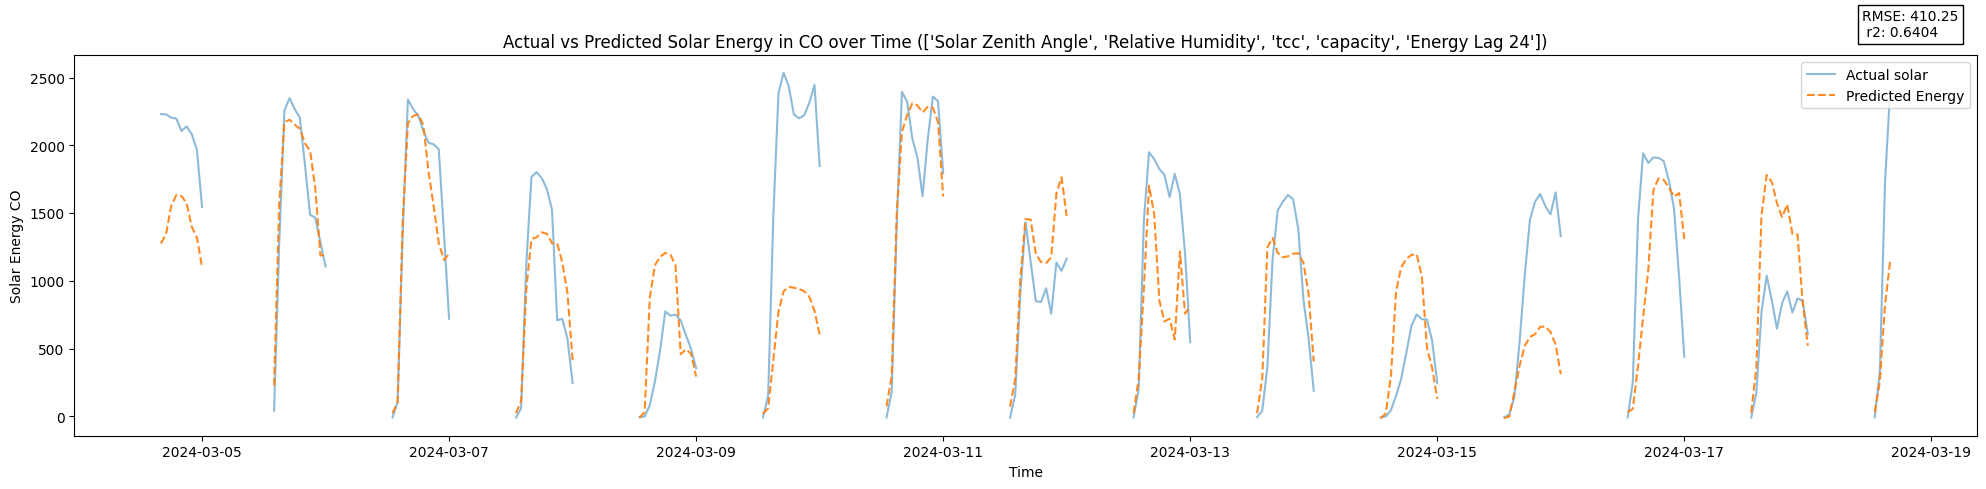

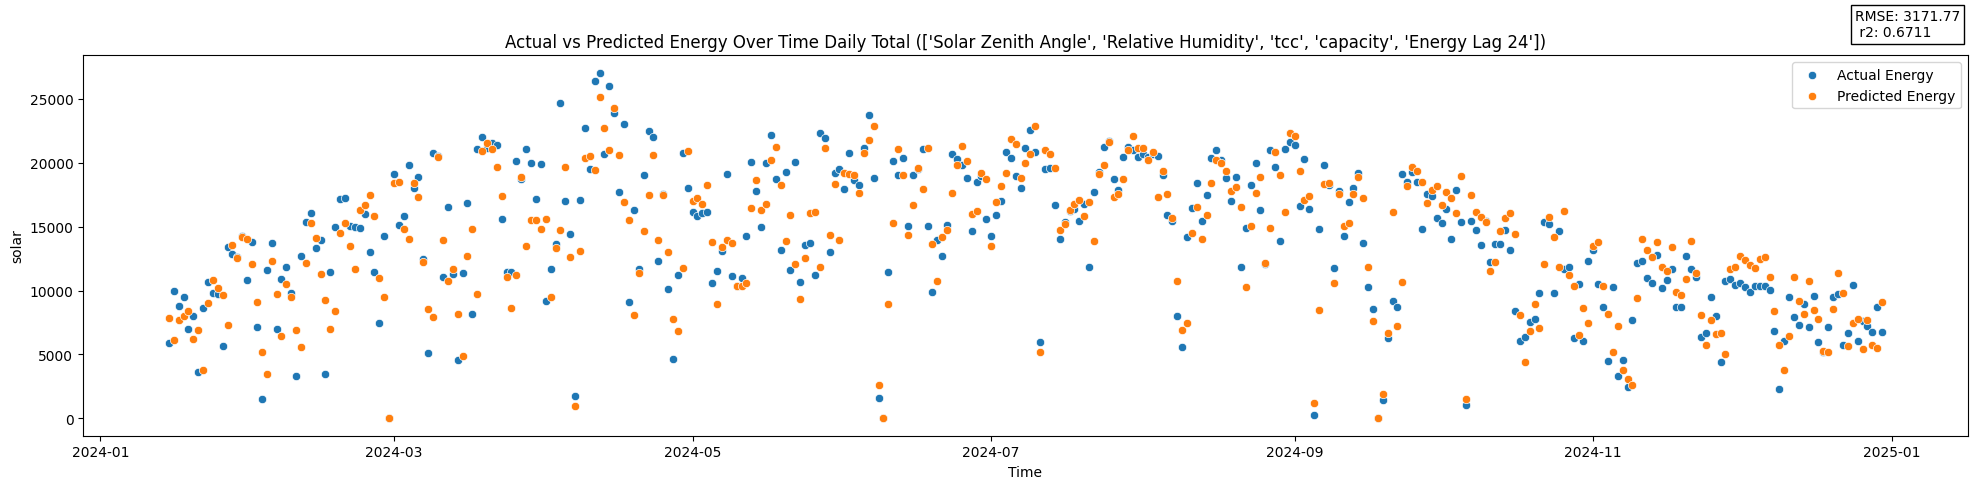

In [29]:
features = ['Solar Zenith Angle','Relative Humidity','tcc', 'capacity', 'Energy Lag 24']
XGBoostModels2.fit(features)

plot_data2(features,XGBoostModels2.predictions(features))
plot_daily_data2(features,XGBoostModels2.predictions(features))



The previous case is the best one so far

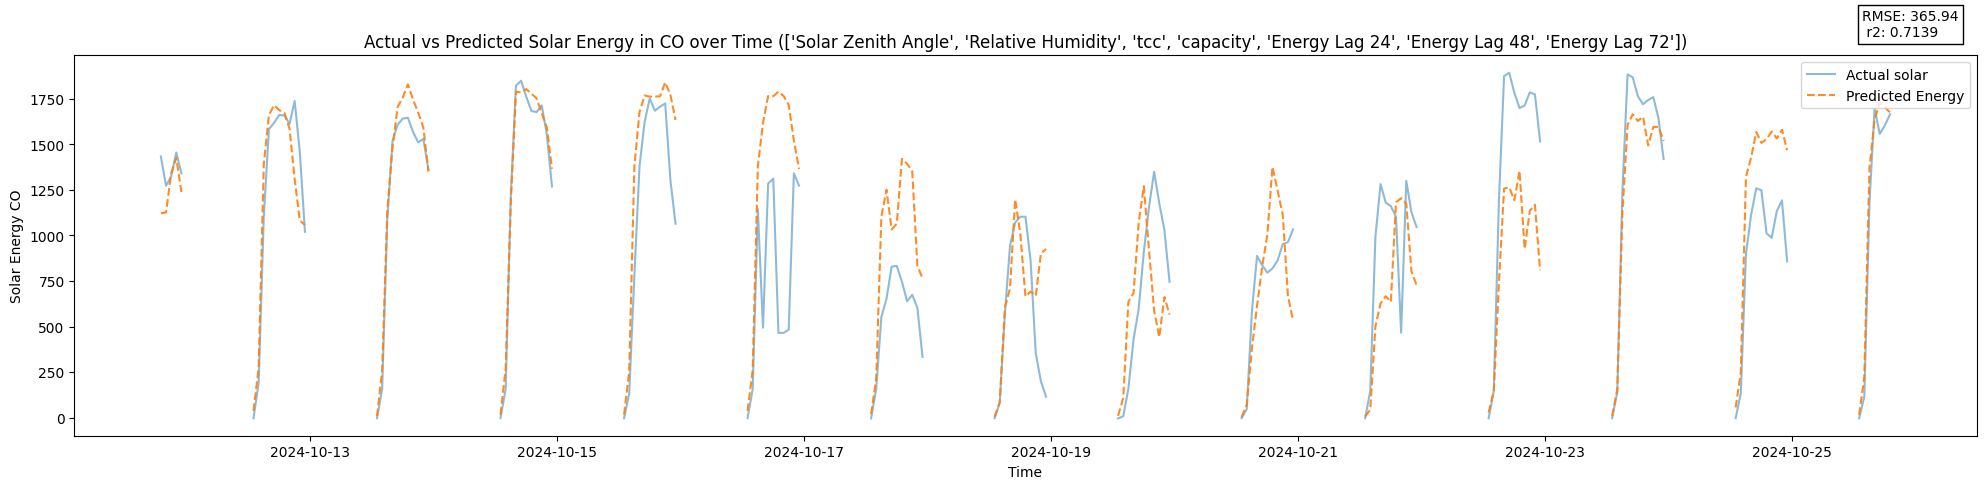

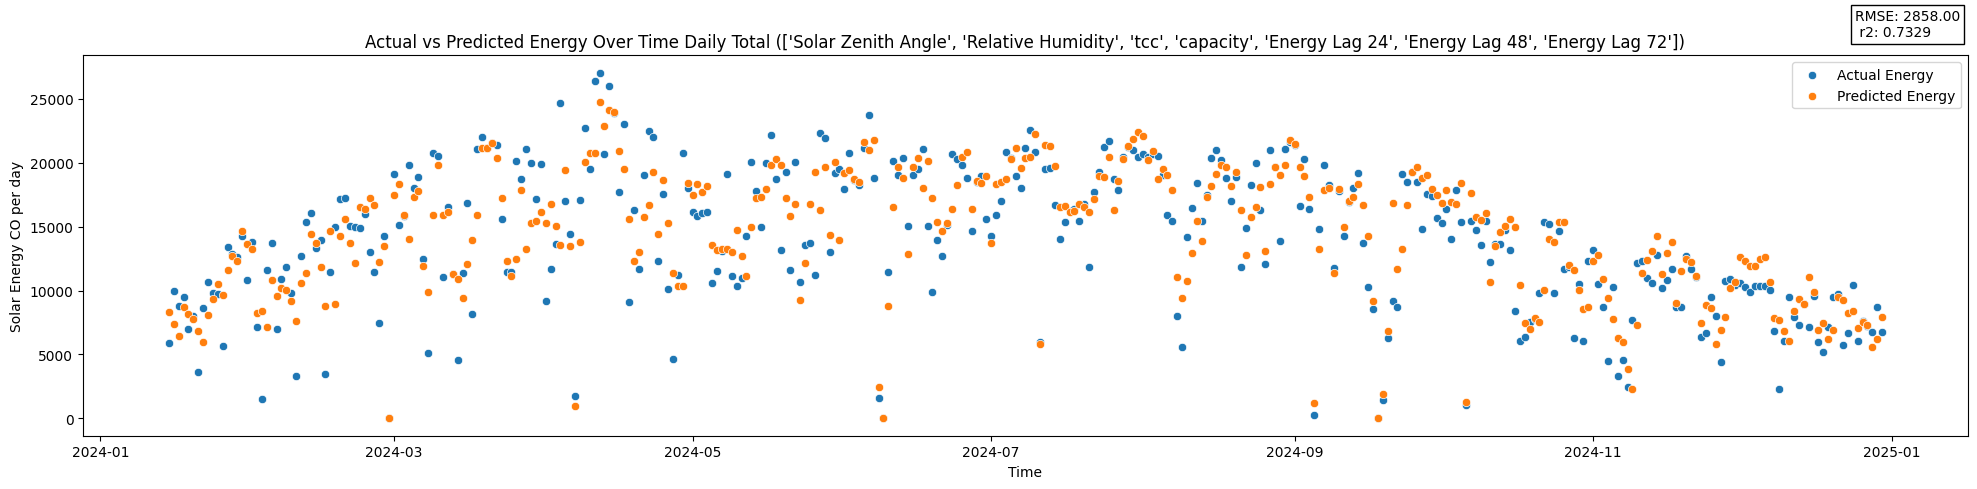

In [5]:
features = ['Solar Zenith Angle','Relative Humidity','tcc','capacity','Energy Lag 24', 'Energy Lag 48', 'Energy Lag 72' ]
XGBoostModels2.fit(features)

plot_data2(features,XGBoostModels2.predictions(features))
plot_daily_data2(features,XGBoostModels2.predictions(features))

Now, we consider the net demand 

In [6]:


class ForestRegressions3:
    def __init__(self, df_train:pd.DataFrame, df_test:pd.DataFrame):
        self.df_train = df_train
        self.df_test = df_test
        self.features = df_train.columns
        self.models = {}

    def fit(self,feature_list:list, param_list=None):

        tscv = TimeSeriesSplit(n_splits=5)

        X_train = self.df_train[feature_list]
        y_train = self.df_train['net']
        
        if param_list is None:
            param_list = {
            'n_estimators': [50, 100, 200],
            'max_depth': [2, 5, 10],
            'min_samples_split': [3, 4, 10],
            'min_samples_leaf': [3, 4, 10]}

        search = GridSearchCV(RandomForestRegressor(),param_grid=param_list,cv=tscv,scoring='neg_root_mean_squared_error',n_jobs=-1)
        search.fit(X_train,y_train)
        
        self.models[tuple(feature_list)] = search.best_estimator_

    def get_model(self, feature_list:list):
        return self.models.get(tuple(feature_list))
    
    def predictions(self, feature_list:list):
        model = self.get_model(tuple(feature_list))
        df = self.df_test[["net"]].copy()
        df['Prediction'] = model.predict(self.df_test[feature_list])
        return df

class ExtraTreesRegressions3:
    def __init__(self, df_train:pd.DataFrame, df_test:pd.DataFrame):
        self.df_train = df_train
        self.df_test = df_test
        self.features = df_train.columns
        self.models = {}

    def fit(self,feature_list:list, param_list=None):

        tscv = TimeSeriesSplit(n_splits=5)

        X_train = self.df_train[feature_list]
        y_train = self.df_train['net']
        
        if param_list is None:
            param_list = {
            'n_estimators': [50, 100, 200, 500],
            'max_depth': [None, 2, 5],
            'min_samples_split': [3, 4, 10],
            'min_samples_leaf': [3, 4, 10]}

        search = GridSearchCV(ExtraTreesRegressor(),param_grid=param_list,cv=tscv,scoring='neg_root_mean_squared_error',n_jobs=-1)
        search.fit(X_train,y_train)
        
        self.models[tuple(feature_list)] = search.best_estimator_

    def get_model(self, feature_list:list):
        return self.models.get(tuple(feature_list))
    
    def predictions(self, feature_list:list):
        model = self.get_model(tuple(feature_list))
        df = self.df_test[["net"]].copy()
        df['Prediction'] = model.predict(self.df_test[feature_list])
        return df

class XGBoostRegressions3:
    def __init__(self, df_train:pd.DataFrame, df_test:pd.DataFrame):
        self.df_train = df_train
        self.df_test = df_test
        self.features = df_train.columns
        self.models = {}

    def fit(self,feature_list:list, param_list=None):

        tscv = TimeSeriesSplit(n_splits=5)

        X_train = self.df_train[feature_list]
        y_train = self.df_train['net']
        
        if param_list is None:
            param_list = {
                'n_estimators': [100, 200, 300, 400, 500],
                'learning_rate': [0.01, 0.05, 0.1],
                'max_depth': [3, 5, 7],
                'subsample': [0.8, 1.0]}

        search = GridSearchCV(XGBRegressor(),param_grid=param_list,cv=tscv,scoring='neg_root_mean_squared_error',n_jobs=-1)
        search.fit(X_train,y_train)
        
        self.models[tuple(feature_list)] = search.best_estimator_


    def get_model(self, feature_list:list):
        return self.models.get(tuple(feature_list))
    
    def predictions(self, feature_list:list):
        model = self.get_model(tuple(feature_list))
        df = self.df_test[["net"]].copy()
        df['Prediction'] = model.predict(self.df_test[feature_list])
        return df
    
def plot_data3(title:str,df:pd.DataFrame,day=None):
    if day is not None:#Optional day argument starts are chosen day
        start = pd.Timestamp(year=df.index.year[1],month=1,day=1).tz_localize('UTC')+pd.Timedelta(days=day-1)
        end = start+pd.Timedelta(days=14)
    else:#Otherwise randomly choose a day to begin plot
        days = [day for day in df.index.unique() if day.day_of_year < 350]
        start = np.random.choice(days)
        end = start+pd.Timedelta(days=14)
    plot_df = df.asfreq('h')#Add NaN rows so pyplot skips interpolation across jumps
    plot_df = plot_df.loc[start:end]

    #Metrics added to plot labeling
    rmse = root_mean_squared_error(df['net'],df['Prediction'])
    r2 = r2_score(df['net'],df['Prediction'])

    plt.figure(figsize=(20, 5))
    plt.plot(plot_df.index, plot_df['net'], label='Net Demand', alpha=0.5)
    plt.plot(plot_df.index, plot_df['Prediction'], label='Predicted Energy', linestyle='--', alpha=0.9)
    plt.title(f"Actual vs Predicted Solar Energy in CO over Time ({title})")
    plt.xlabel("Time")
    plt.ylabel("Net demand CO")
    plt.text(0.94,1.05,f'RMSE: {rmse:.2f}\n r2: {r2:.4f}',transform=plt.gca().transAxes,bbox=dict(boxstyle="square", facecolor="white"))
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

def plot_daily_data3(title:str,df:pd.DataFrame):
    #Convert dataframe of hourly data to daily data of total energy
    df_daily = df.resample('d').agg('sum')

    #Metrics added to plot labeling
    rmse = root_mean_squared_error(df_daily['net'],df_daily['Prediction'])
    r2 = r2_score(df_daily['net'],df_daily['Prediction'])

    plt.figure(figsize=(20, 5))
    sns.scatterplot(df_daily, x=df_daily.index,y='net',label='Actual Energy')
    sns.scatterplot(df_daily, x=df_daily.index,y='Prediction',label='Predicted Energy')
    plt.title(f"Actual vs Predicted Net Demand Over Time Daily Total ({title})")
    plt.xlabel("Time")
    plt.ylabel("Net demand CO per day")
    plt.text(0.94,1.05,f'RMSE: {rmse:.2f}\n r2: {r2:.4f}',transform=plt.gca().transAxes,bbox=dict(boxstyle="square", facecolor="white"))
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()  

In [7]:
c22['net'] = c22['demand'] - c22['solar']
c23['net'] = c23['demand'] - c23['solar']
c24['net'] = c24['demand'] - c24['solar']

C:\Users\jumo2729\AppData\Local\Temp\ipykernel_1268\2469034092.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c22['net'] = c22['demand'] - c22['solar']
C:\Users\jumo2729\AppData\Local\Temp\ipykernel_1268\2469034092.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c23['net'] = c23['demand'] - c23['solar']
C:\Users\jumo2729\AppData\Local\Temp\ipykernel_1268\2469034092.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

In [8]:
SolarTrainA = pd.concat([c22, c23])
SolarTestA = c24.copy()

RandomForestModels3 = ForestRegressions3(SolarTrainA,SolarTestA)
ExtraTreeModels3 = ExtraTreesRegressions3(SolarTrainA,SolarTestA)
XGBoostModels3 = XGBoostRegressions3(SolarTrainA,SolarTestA)

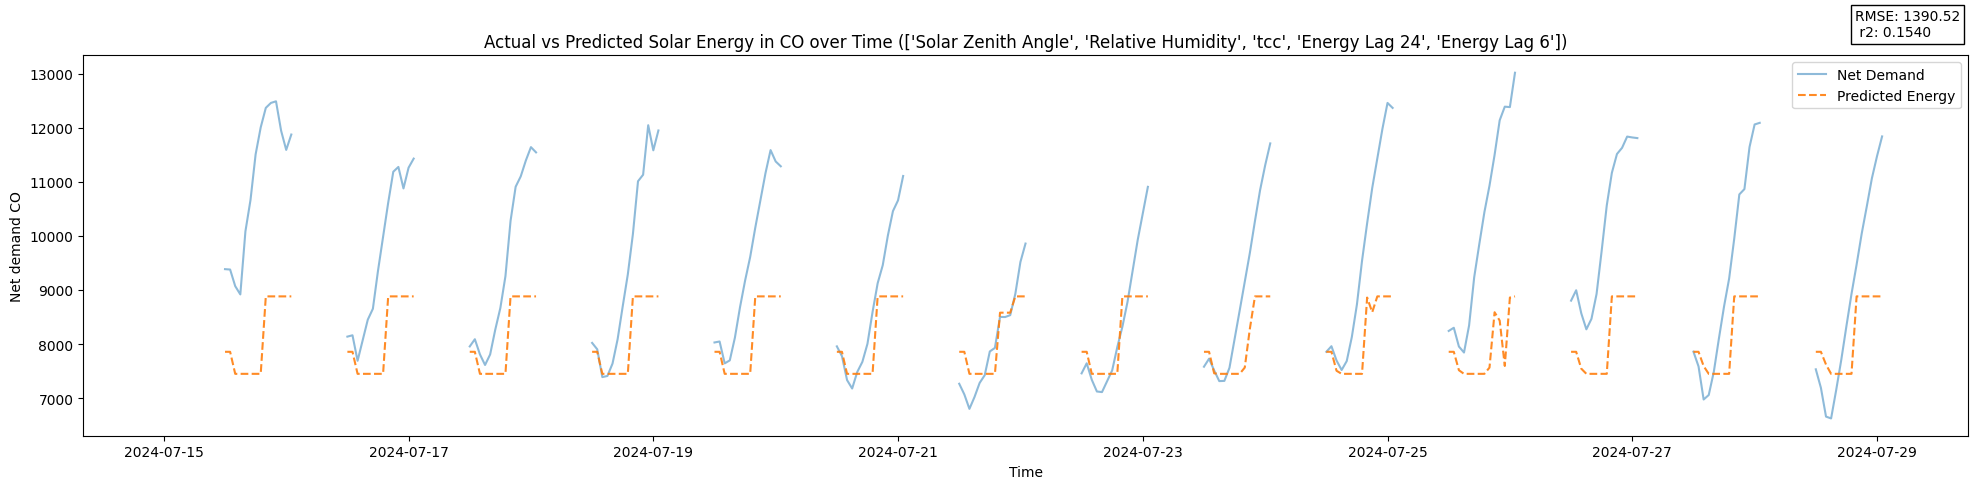

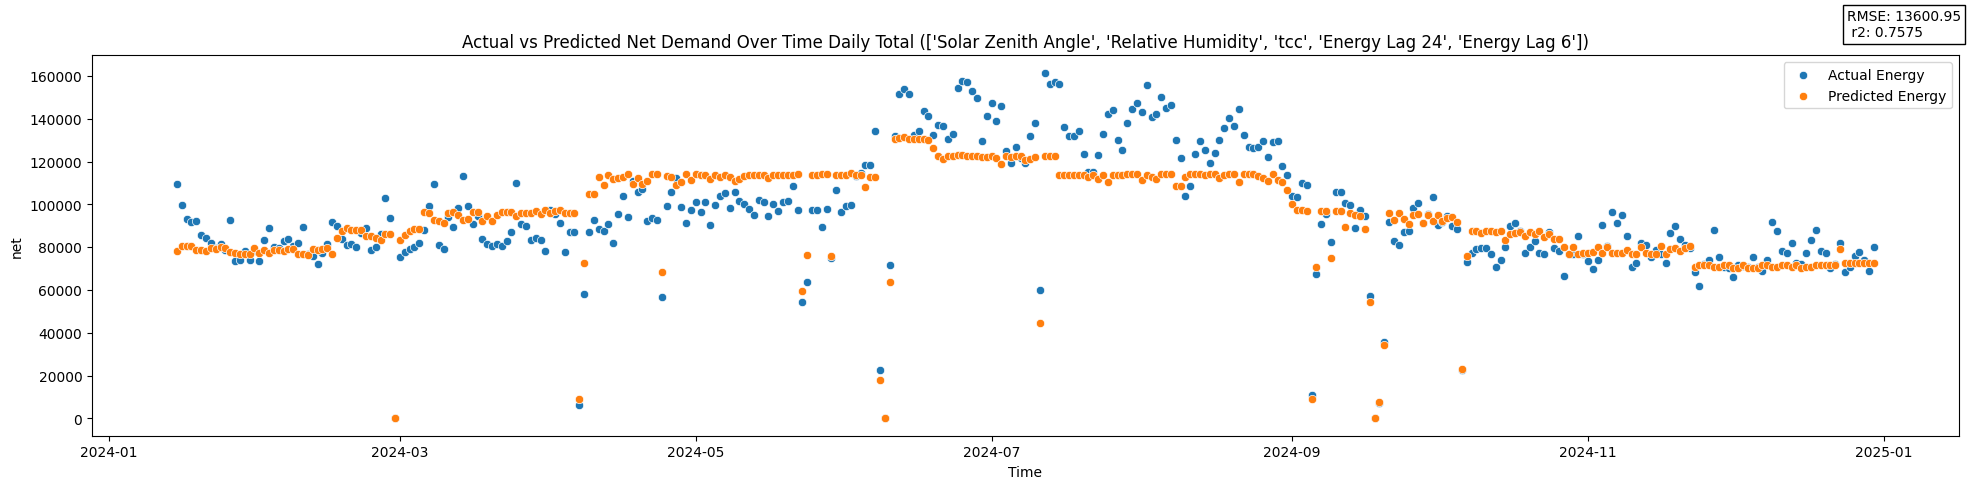

In [35]:
features = ['Solar Zenith Angle', 'Relative Humidity', 'tcc','Energy Lag 24', 'Energy Lag 6']
RandomForestModels3.fit(features)

plot_data3(features,RandomForestModels3.predictions(features))
plot_daily_data3(features,RandomForestModels3.predictions(features))

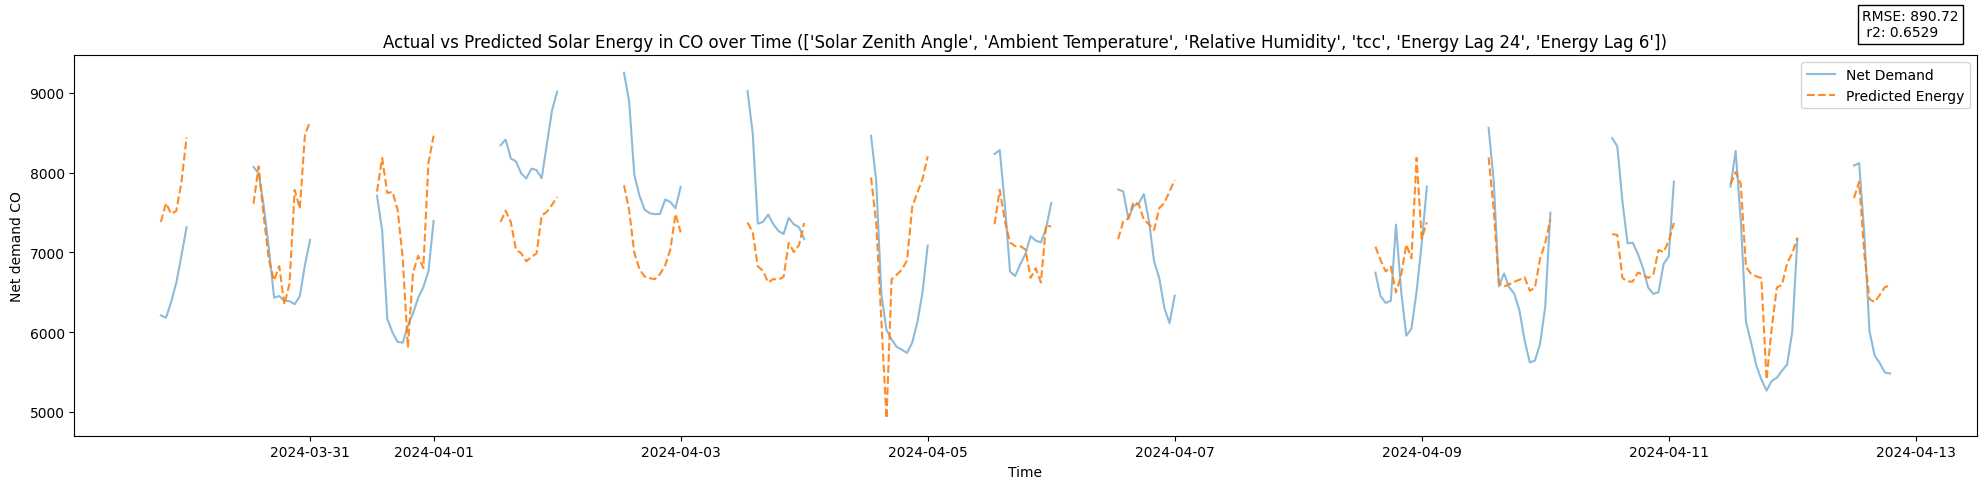

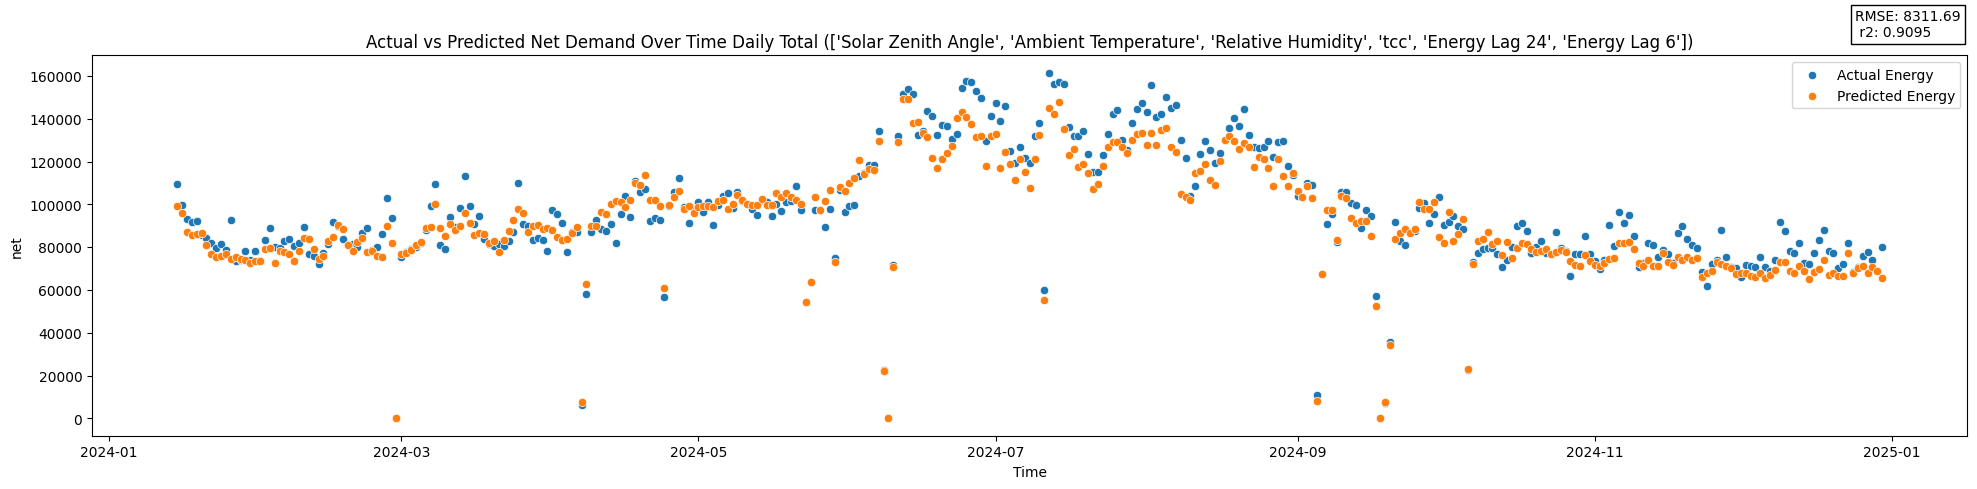

In [36]:
features = ['Solar Zenith Angle', 'Ambient Temperature', 'Relative Humidity', 'tcc','Energy Lag 24', 'Energy Lag 6']
RandomForestModels3.fit(features)

plot_data3(features,RandomForestModels3.predictions(features))
plot_daily_data3(features,RandomForestModels3.predictions(features))

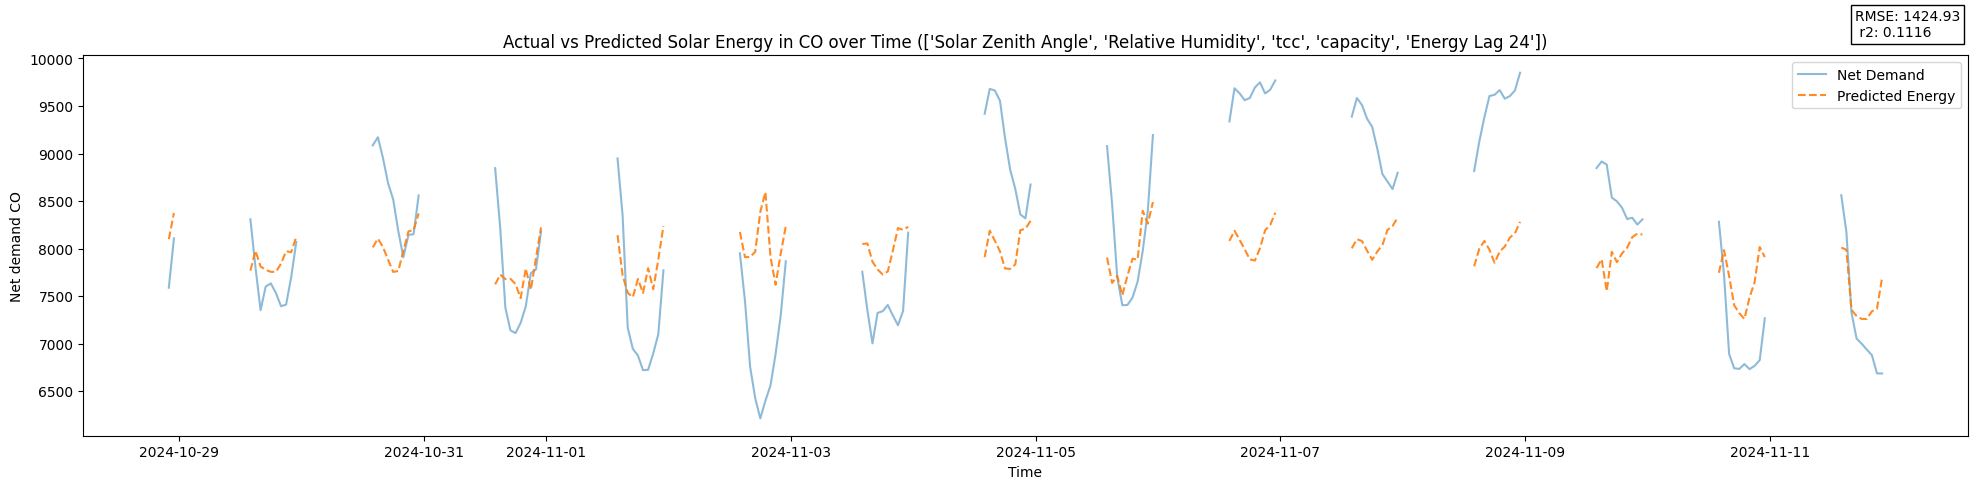

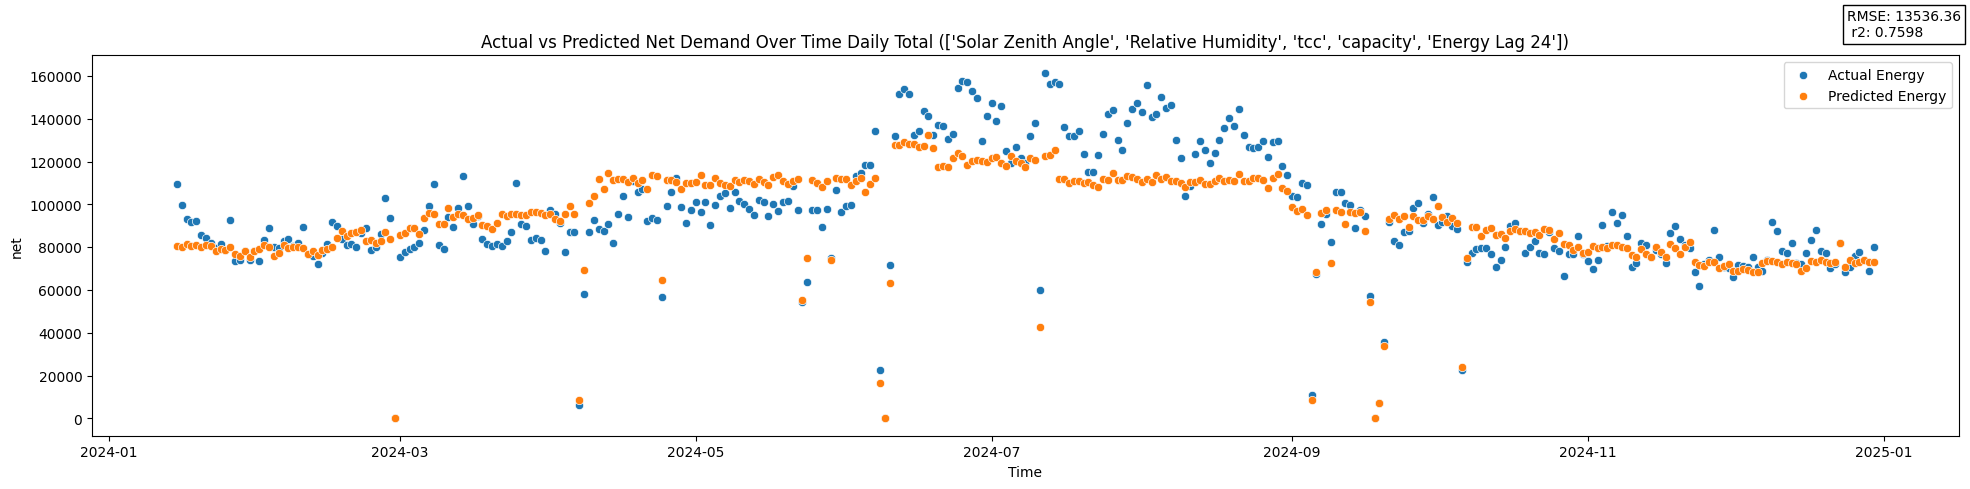

In [37]:
features = ['Solar Zenith Angle','Relative Humidity','tcc', 'capacity', 'Energy Lag 24']
XGBoostModels3.fit(features)

plot_data3(features,XGBoostModels3.predictions(features))
plot_daily_data3(features,XGBoostModels3.predictions(features))

In [1]:
features = ['Solar Zenith Angle','Relative Humidity','Ambient Temperature','tcc', 'capacity', 'Energy Lag 24']
XGBoostModels3.fit(features)

plot_data3(features,XGBoostModels3.predictions(features))
plot_daily_data3(features,XGBoostModels3.predictions(features))

NameError: name 'XGBoostModels3' is not defined

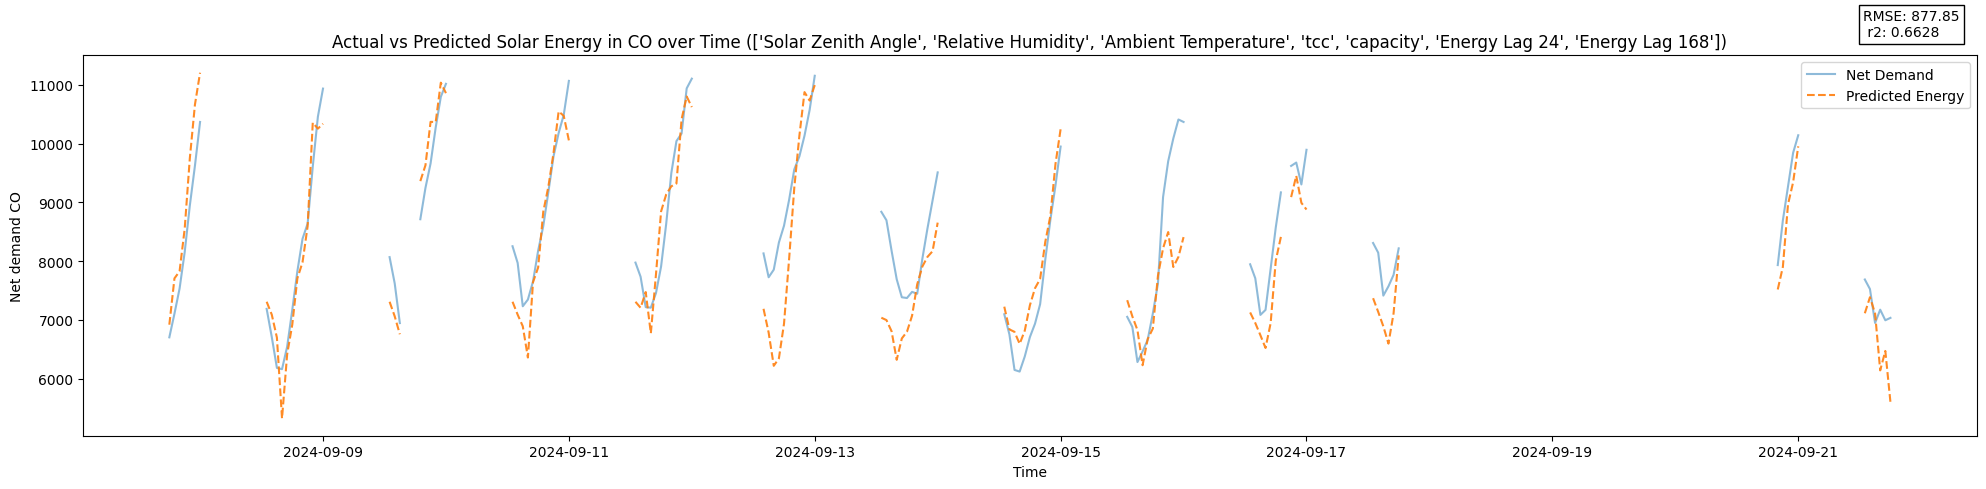

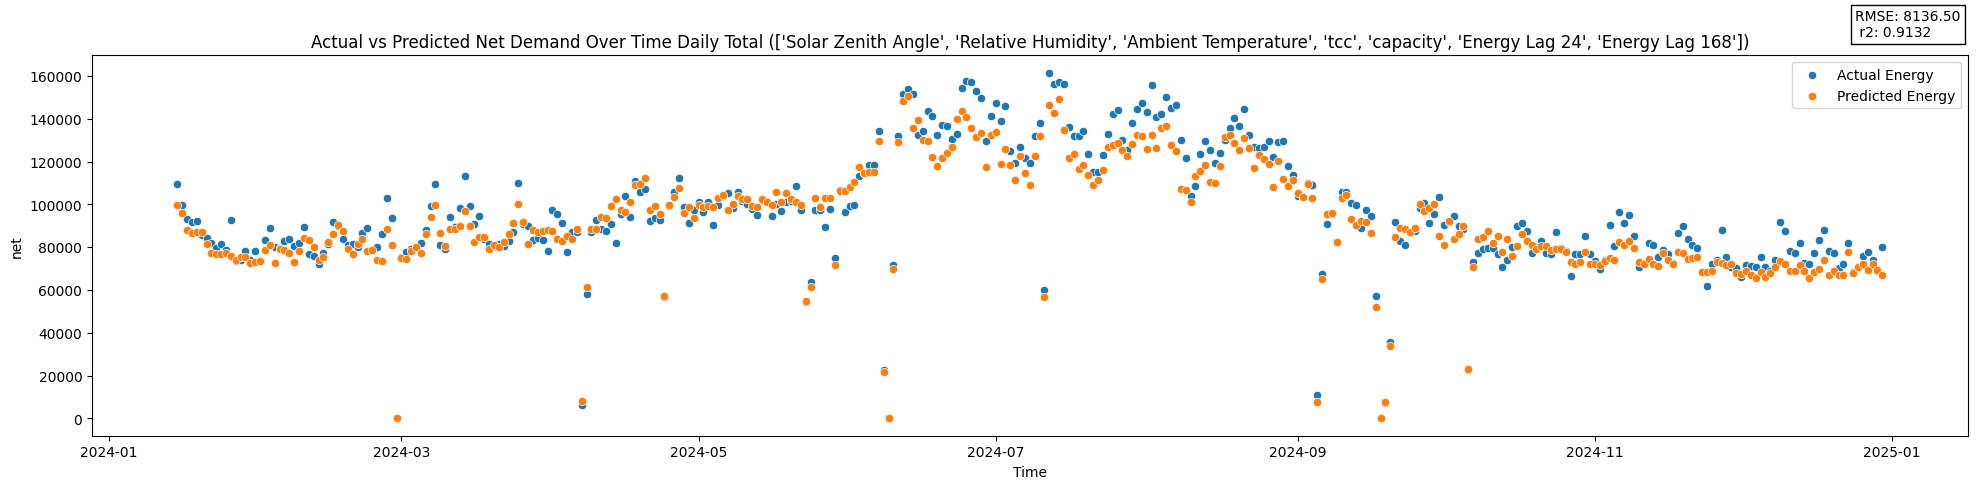

In [24]:
features = ['Solar Zenith Angle','Relative Humidity','Ambient Temperature','tcc', 'capacity', 'Energy Lag 24', 'Energy Lag 168']
XGBoostModels3.fit(features)

plot_data3(features,XGBoostModels3.predictions(features))
plot_daily_data3(features,XGBoostModels3.predictions(features))

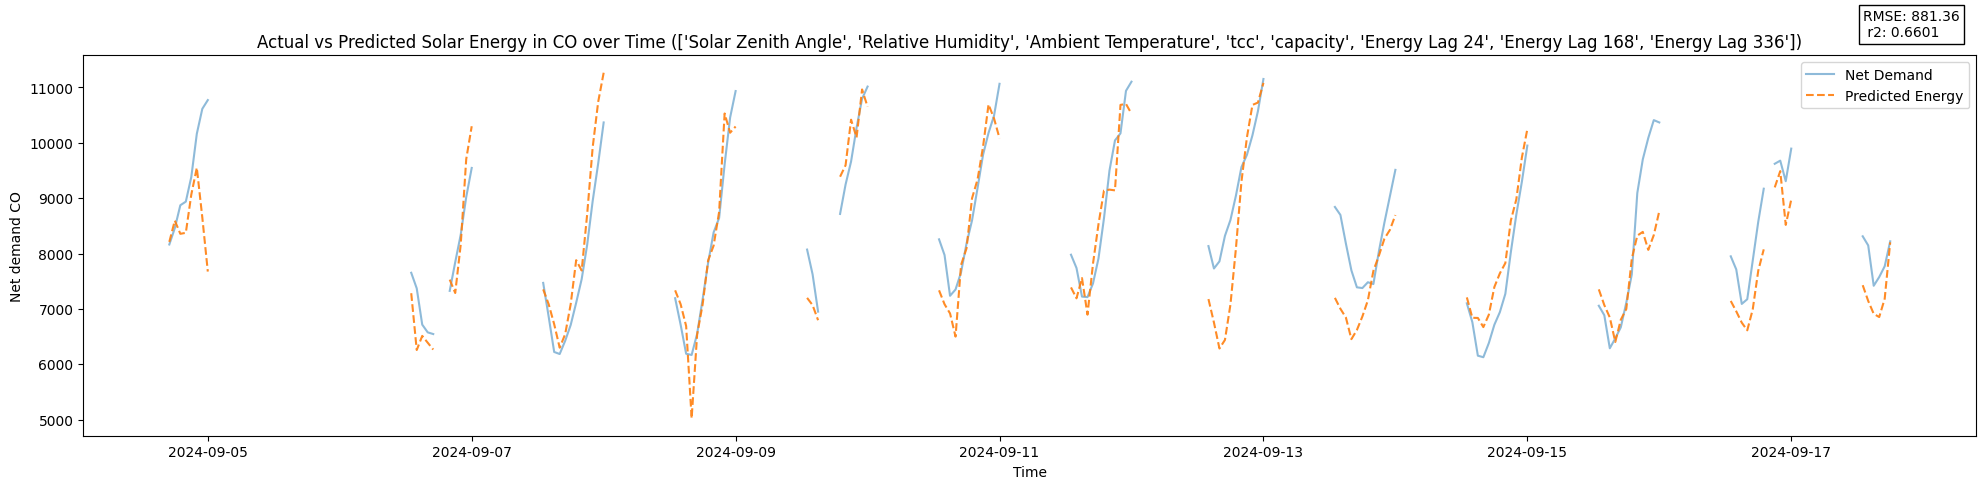

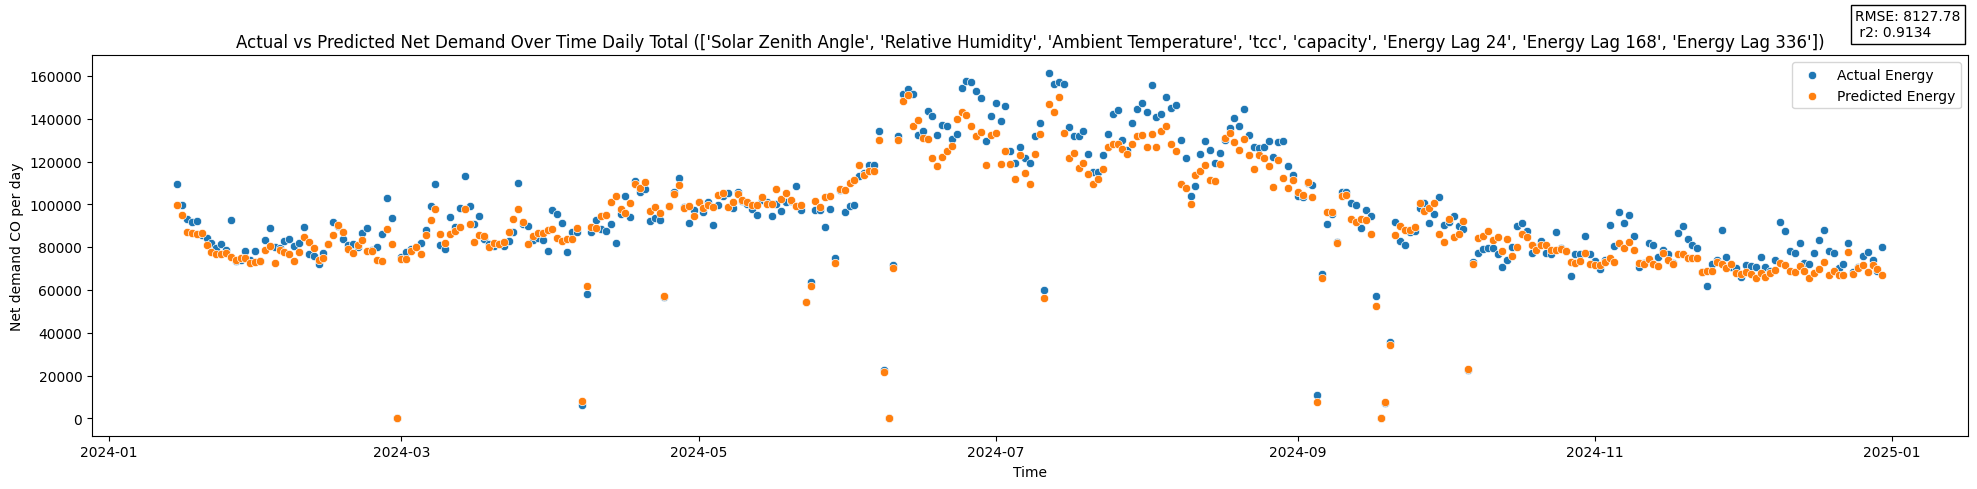

In [9]:
features = ['Solar Zenith Angle','Relative Humidity','Ambient Temperature','tcc', 'capacity', 'Energy Lag 24', 'Energy Lag 168' , 'Energy Lag 336']
XGBoostModels3.fit(features)

plot_data3(features,XGBoostModels3.predictions(features))
plot_daily_data3(features,XGBoostModels3.predictions(features))